# Регуляризация: МНК, L2 (ridge) и L1 (lasso)

Полиномиальная модель с большим числом степеней легко переобучается: веса раздуваются,
кривая начинает осциллировать между точками. Регуляризация добавляет к функционалу
штраф за большие веса:

$$Q_\lambda(w) = \frac{1}{n}\sum_i \big(a(x_i) - y_i\big)^2 + \lambda \sum_j |w_j|^q$$

- $q = 2$ — **L2 (ridge)**: веса сжимаются к нулю, но не зануляются;
- $q = 1$ — **L1 (lasso)**: часть весов зануляется точно, получается отбор признаков.

Свободный член $w_0$ штрафовать не принято — он отвечает за сдвиг, а не за сложность
кривой. Всё на чистом numpy.


## 1. Метод наименьших квадратов (аналитическое решение)

Для квадратичного функционала минимум можно найти без итераций, одной матричной
формулой: $w = (S^{\top} S)^{-1} S^{\top} y$. Аппроксимирую
$f(x) = 0.5x + 0.2x^2 - 0.05x^3 + 0.2\sin 4x - 2.5$ кубическим полиномом.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def func(x):
    return 0.5 * x + 0.2 * x ** 2 - 0.05 * x ** 3 + 0.2 * np.sin(4 * x) - 2.5


coord_x = np.arange(-4.0, 6.0, 0.1)
coord_y = func(coord_x)

# матрица признаков [1, x, x^2, x^3]
x_train = np.array([[x ** i for i in range(4)] for x in coord_x])
y_train = coord_y

# аналитическое решение МНК
w = np.linalg.inv(x_train.T @ x_train) @ x_train.T @ y_train

Q = np.mean((x_train @ w - y_train) ** 2)
print(f"MSE: {Q:.6f}")
print(f"веса: {np.round(w, 4)}")
print("(истинные коэффициенты при 1, x, x², x³: -2.5, 0.5, 0.2, -0.05)")


MSE: 0.019663
веса: [-2.4921  0.5034  0.1978 -0.0499]
(истинные коэффициенты при 1, x, x², x³: -2.5, 0.5, 0.2, -0.05)


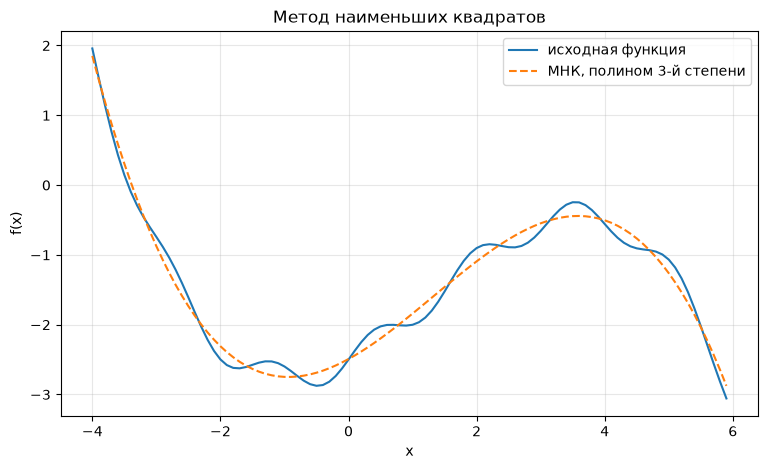

In [2]:
plt.figure(figsize=(9, 5))
plt.plot(coord_x, coord_y, label="исходная функция")
plt.plot(coord_x, x_train @ w, "--", label="МНК, полином 3-й степени")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Метод наименьших квадратов")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


МНК восстановил коэффициенты полинома почти точно — остаётся только
ошибка от члена $0.2\sin 4x$, которого нет в базисе. Но у аналитического решения есть
слабость: обращение матрицы $S^{\top}S$ становится неустойчивым, когда признаков много
и они коррелируют. Именно там и помогает L2.

## 2. L2-регуляризация (ridge): полином 21-й степени

Нарочно беру избыточно сложную модель — полином степени 21 для функции
$f(x) = 0.1x + 0.1x^2 - 0.5\sin 2x + \cos 4x + 10$. Обучающая выборка — каждая вторая
точка. Решение со штрафом: $w = (S^{\top}S + \lambda I)^{-1} S^{\top}y$,
причём первый диагональный элемент $\lambda I$ обнуляю, чтобы не штрафовать $w_0$.

Сравниваю с решением без штрафа ($\lambda = 0$).


In [3]:
def func2(x):
    return 0.1 * x + 0.1 * x ** 2 - 0.5 * np.sin(2 * x) + np.cos(4 * x) + 10


x = np.arange(-3.0, 4.1, 0.1)
y = func2(x)

N_feat = 22  # размер признакового пространства (полином степени 21)
lm = 20      # параметр L2-регуляризатора

X = np.array([[a ** n for n in range(N_feat)] for a in x])
IL = lm * np.eye(N_feat)
IL[0][0] = 0  # свободный член не регуляризуем

X_train = X[::2]   # обучающая выборка — каждая вторая точка
Y_train = y[::2]

# решение с L2-штрафом и без него
w_l2 = np.linalg.inv(X_train.T @ X_train + IL) @ X_train.T @ Y_train
w_plain = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train

Q_train_l2 = np.mean((X_train @ w_l2 - Y_train) ** 2)
Q_all_l2 = np.mean((X @ w_l2 - y) ** 2)
Q_train_plain = np.mean((X_train @ w_plain - Y_train) ** 2)
Q_all_plain = np.mean((X @ w_plain - y) ** 2)

print(f"без регуляризации:  MSE(train) = {Q_train_plain:.4f}, MSE(все точки) = {Q_all_plain:.4f}")
print(f"с L2, lambda = 20:  MSE(train) = {Q_train_l2:.4f}, MSE(все точки) = {Q_all_l2:.4f}")
print(f"максимальный |w| без штрафа: {np.max(np.abs(w_plain)):.2e}")
print(f"максимальный |w| со штрафом: {np.max(np.abs(w_l2)):.2e}")


без регуляризации:  MSE(train) = 1600.1430, MSE(все точки) = 1605.7943
с L2, lambda = 20:  MSE(train) = 0.7189, MSE(все точки) = 0.7300
максимальный |w| без штрафа: 7.90e+01
максимальный |w| со штрафом: 1.14e+01


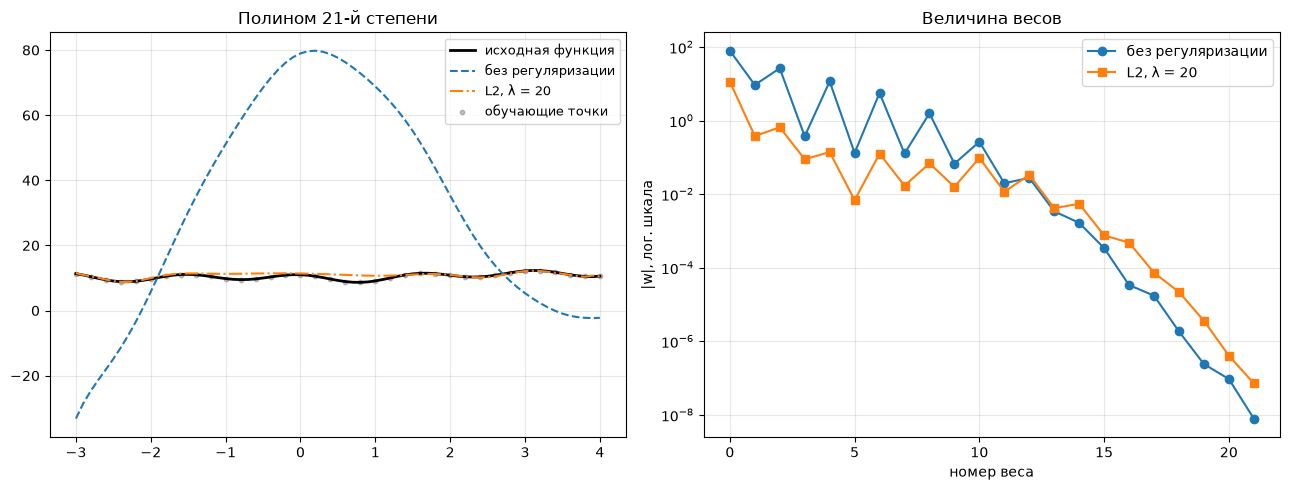

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(x, y, "k-", lw=2, label="исходная функция")
ax[0].plot(x, X @ w_plain, "--", label="без регуляризации")
ax[0].plot(x, X @ w_l2, "-.", label="L2, λ = 20")
ax[0].scatter(x[::2], y[::2], s=10, c="gray", alpha=0.5, label="обучающие точки")
ax[0].set_title("Полином 21-й степени")
ax[0].legend(fontsize=9)
ax[0].grid(alpha=0.3)

ax[1].semilogy(np.abs(w_plain), "o-", label="без регуляризации")
ax[1].semilogy(np.abs(w_l2), "s-", label="L2, λ = 20")
ax[1].set_xlabel("номер веса")
ax[1].set_ylabel("|w|, лог. шкала")
ax[1].set_title("Величина весов")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Результат вышел даже жёстче обычного примера про переобучение: матрица
$S^{\top}S$ со степенями до $x^{21}$ настолько плохо обусловлена, что без штрафа её
обращение даёт численный мусор — MSE около 1600 даже на обучающих точках. L2-штраф
чинит обусловленность: ошибка падает до ~0.72, веса сжимаются, кривая становится
гладкой. И она хорошо ведёт себя не только в обучающих узлах: MSE на всех точках
отрезка почти такая же, то есть регуляризованная кривая не гуляет между ними.

## 3. L1-регуляризация в классификации (SGD + штраф $\lambda \sum |w_j|$)

Возвращаюсь к данным про цветки, но добавляю к двум признакам ещё два зависимых:
$0.8 x_1$ и $(x_1 + x_2)/2$. Полезной информации они не несут — интересно, что
сделает с их весами L1. Производная $|w|$ — это $\mathrm{sign}(w)$, её и добавляю
к градиенту. Обучение — мини-батч SGD с логарифмической функцией потерь, 3000
итераций (с исходными 500 сжатие видно слабее — проверено).


In [5]:
data_x = [(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)]
data_y = [-1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1]

# признаки [1, x1, x2, 0.8*x1, (x1+x2)/2] — два последних линейно зависимы с первыми
x_train3 = np.array([[1, x[0], x[1], 0.8 * x[0], (x[0] + x[1]) / 2] for x in data_x])
y_train3 = np.array(data_y)
n_train3 = len(x_train3)


In [6]:
def loss_log(w, x, y):
    M = np.dot(x, w) * y
    return np.log2(1 + np.exp(-M))


def df_log(w, x, y):
    M = np.dot(x, w) * y
    return -(np.exp(-M) * x.T * y) / ((1 + np.exp(-M)) * np.log(2))


def train_sgd_l1(lm_l1, n_iter=3000):
    # мини-батч SGD с L1-штрафом; lm_l1 = 0 соответствует обучению без штрафа
    w = np.zeros(x_train3.shape[1])
    nt = np.array([0.5] + [0.01] * (len(w) - 1))
    np.random.seed(0)
    for _ in range(n_iter):
        k = np.random.randint(0, n_train3 - 10 - 1)
        x = x_train3[k:k + 10]
        y = y_train3[k:k + 10]

        # градиент по батчу: df возвращает матрицу (признаки x объекты)
        dQ = np.sum(df_log(w, x, y), axis=1) / len(x)

        l_reg = np.sign(w)
        l_reg[0] = 0  # w0 не штрафуем

        w = w - nt * (dQ + lm_l1 * l_reg)
    return w


w_no_reg = train_sgd_l1(0.0)
w_l1 = train_sgd_l1(0.2)

for name, w in (("без штрафа", w_no_reg), ("L1, λ = 0.2", w_l1)):
    margins = x_train3 @ w * y_train3
    print(f"{name}: доля ошибок = {np.mean(margins < 0):.4f}, веса = {np.round(w, 4)}")


без штрафа: доля ошибок = 0.0800, веса = [-11.314    0.0647   2.9483   0.0518   1.5065]
L1, λ = 0.2: доля ошибок = 0.1200, веса = [-1.3843  0.009   0.5866  0.0036  0.1098]


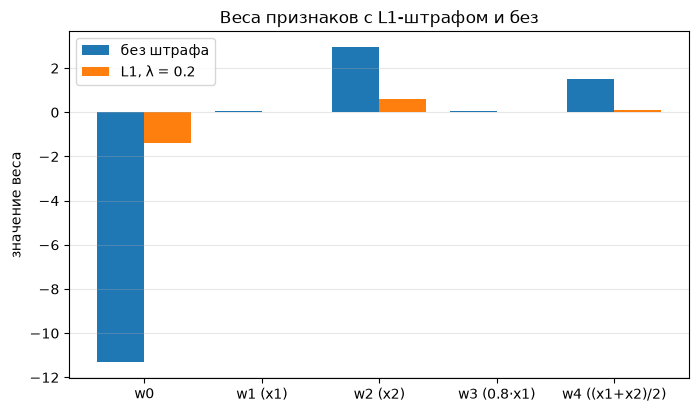

In [7]:
labels = ["w0", "w1 (x1)", "w2 (x2)", "w3 (0.8·x1)", "w4 ((x1+x2)/2)"]
xpos = np.arange(len(labels))

plt.figure(figsize=(8, 4.5))
plt.bar(xpos - 0.2, w_no_reg, width=0.4, label="без штрафа")
plt.bar(xpos + 0.2, w_l1, width=0.4, label="L1, λ = 0.2")
plt.xticks(xpos, labels)
plt.ylabel("значение веса")
plt.title("Веса признаков с L1-штрафом и без")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.show()


Видно, как L1 давит именно лишние признаки: веса при $0.8x_1$ и
$(x_1+x_2)/2$ со штрафом на порядок меньше, чем без него (0.004 против 0.05 и 0.11
против 1.5), а рабочие $w_1, w_2$ остаются. Доля ошибок при этом выросла
незначительно. Честное замечание: субградиентный SGD не зануляет веса до последнего
знака, как это делает координатный спуск в классическом lasso, но порядок величин
говорит сам за себя. А вот при слишком большом $\lambda$ (пробовал 0.5) штраф
задавил вообще все веса, и доля ошибок скакнула до 0.5 — коэффициент регуляризации
надо выбирать аккуратно.

## 4. L1-регуляризация в регрессии

Тот же штраф, но для аппроксимации $f(x) = -0.5x^2 + 0.1x^3 + \cos 3x + 7$
полиномом 4-й степени. Лишних признаков нет, и здесь вскрывается другой эффект:
с жёстко фиксированными шагами $\eta$ процесс чувствителен к бюджету итераций, и за
отведенные 500 шагов без штрафа веса ещё не сошлись. L1 на этом бюджете работает
как стабилизатор — не даёт весам старших степеней разноситься.


In [8]:
def func4(x):
    return -0.5 * x ** 2 + 0.1 * x ** 3 + np.cos(3 * x) + 7


def model(w, x):
    xv = np.array([x ** n for n in range(len(w))])
    return w.T @ xv


def loss_sq(w, x, y):
    return (model(w, x) - y) ** 2


def dloss_sq(w, x, y):
    xv = np.array([x ** n for n in range(len(w))])
    return 2 * (model(w, x) - y) * xv


coord_x4 = np.arange(-4.0, 6.0, 0.1)
coord_y4 = func4(coord_x4)

N_feat4 = 5       # полином степени 4
lm_l1_4 = 2.0     # коэффициент L1-регуляризатора
sz4 = len(coord_x4)
eta4 = np.array([0.1, 0.01, 0.001, 0.0001, 0.000002])
batch_size4 = 20
lm_ema = 0.02


def train_reg_l1(lm_l1):
    # мини-батч SGD по квадратичной потере с L1-штрафом
    w = np.zeros(N_feat4)
    np.random.seed(0)
    Qe = np.mean(loss_sq(w, coord_x4, coord_y4))
    for _ in range(500):
        k = np.random.randint(0, sz4 - batch_size4 - 1)
        x = coord_x4[k:k + batch_size4]
        y = coord_y4[k:k + batch_size4]

        Qk = np.mean(loss_sq(w, x, y))
        Qe = Qk * lm_ema + (1 - lm_ema) * Qe

        dQ = np.sum(dloss_sq(w, x, y), axis=1) / batch_size4

        l_reg = np.sign(w)
        l_reg[0] = 0

        w = w - eta4 * (dQ + lm_l1 * l_reg)
    return w


w_plain4 = train_reg_l1(0.0)
w_l1_4 = train_reg_l1(lm_l1_4)

Q_plain4 = np.mean(loss_sq(w_plain4, coord_x4, coord_y4))
Q_l1_4 = np.mean(loss_sq(w_l1_4, coord_x4, coord_y4))
print(f"без штрафа:    MSE = {Q_plain4:.5f}, веса = {np.round(w_plain4, 4)}")
print(f"L1, λ = 2.0:   MSE = {Q_l1_4:.5f}, веса = {np.round(w_l1_4, 4)}")


без штрафа:    MSE = 78.14607, веса = [ 2.7461 -1.9855 -0.8177  0.0972  0.0128]
L1, λ = 2.0:   MSE = 0.93598, веса = [ 6.7252  0.04   -0.3084  0.1032 -0.0074]


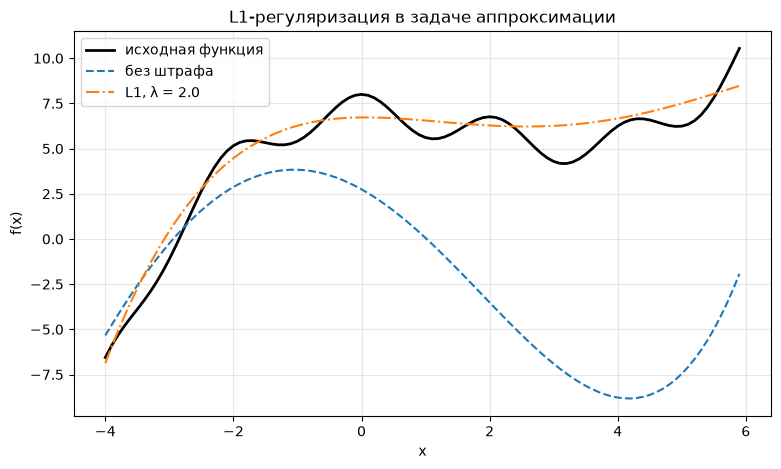

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(coord_x4, coord_y4, "k-", lw=2, label="исходная функция")
plt.plot(coord_x4, model(w_plain4, coord_x4), "--", label="без штрафа")
plt.plot(coord_x4, model(w_l1_4, coord_x4), "-.", label="L1, λ = 2.0")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("L1-регуляризация в задаче аппроксимации")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Выводы

- МНК даёт точное решение за один шаг, но требует обращения матрицы $S^{\top}S$ —
  на плохо обусловленных признаках это ломается.
- L2-регуляризация чинит плохую обусловленность задачи: без штрафа обращение
  $S^{\top}S$ для полинома 21-й степени дало численный мусор (MSE ~1600 даже на
  обучающих точках), со штрафом $\lambda = 20$ ошибка упала до ~0.72, а веса
  сжались на порядки.
- L1-регуляризация в классификации придавила веса линейно зависимых признаков на
  порядок без заметной потери качества — по сути выполнила отбор признаков.
  Но при слишком большом $\lambda$ модель деградирует: при $\lambda = 0.5$ доля
  ошибок выросла до 0.5.
- Свободный член $w_0$ штрафовать нельзя: он не усложняет модель, а отвечает за
  сдвиг — во всех примерах он исключён из штрафа.
- В регрессии с фиксированными шагами $\eta$ штраф L1 сыграл роль стабилизатора
  на ограниченном числе итераций. Общий урок: $\lambda$ и шаги обучения надо
  подбирать вместе и следить за сходимостью.
